In [1]:
%load_ext autoreload
%autoreload 2

In [37]:
from mad.utils import load_ballistic_table, BALLISTIC_FIELD_NAMES
from mad.objs.constants import EARTH_SETTINGS
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

In [38]:
table = load_ballistic_table("titan_stage_2")
df = pd.DataFrame({k:table[:, i] for i, k in enumerate(BALLISTIC_FIELD_NAMES)})

In [39]:

df["range_km"] = df["range_rad"] * EARTH_SETTINGS["radius"] / 1000
df["altitude_km"] = df["altitude_m"] / 1000
df["gamma_deg"] = df["gamma_rad"] * 180 / np.pi


In [50]:
selected_altitude = 00
df2 = df[df["altitude_km"] == selected_altitude].pivot(index="velocity_m_s", columns="gamma_deg", values="range_km")


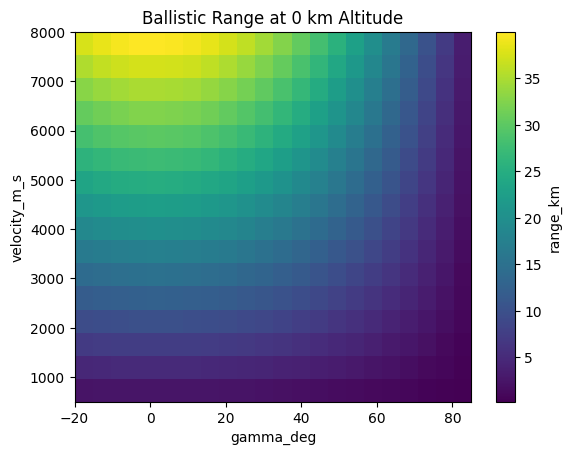

In [51]:
fig, ax = plt.subplots()
img = ax.imshow(df2.values, extent=(df2.columns.min(), df2.columns.max(), df2.index.min(), df2.index.max()), aspect="auto", origin="lower")
ax.set_xlabel("gamma_deg")
ax.set_ylabel("velocity_m_s")
cbar = fig.colorbar(img, ax=ax)
cbar.set_label("range_km")
ax.set_title(f"Ballistic Range at {selected_altitude} km Altitude")
plt.show()